# Дерево решений

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error,  r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.impute import SimpleImputer

In [12]:
csv_path = Path("Housing.csv")
df = pd.read_csv(csv_path)
target_col = "price"
y = df[target_col].values
X = df.drop(columns=[target_col, "rownames"])
X.head(), target_col

(   lotsize  bedrooms  bathrms  stories driveway recroom fullbase gashw airco  \
 0     5850         3        1        2      yes      no      yes    no    no   
 1     4000         2        1        1      yes      no       no    no    no   
 2     3060         3        1        1      yes      no       no    no    no   
 3     6650         3        1        2      yes     yes       no    no    no   
 4     6360         2        1        1      yes      no       no    no    no   
 
    garagepl prefarea  
 0         1       no  
 1         0       no  
 2         0       no  
 3         0       no  
 4         0       no  ,
 'price')

In [13]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_features, categorical_features

(['lotsize', 'bedrooms', 'bathrms', 'stories', 'garagepl'],
 ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea'])

In [14]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
reg = DecisionTreeRegressor(criterion="squared_error", random_state=42)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", reg)
])

param_grid = {
    "tree__max_depth": [3, 5, 7, None],
    "tree__min_samples_split": [2, 5, 10],
    "tree__min_samples_leaf": [1, 3, 5, 10]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe, param_grid= param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
grid_search.best_params_

{'tree__max_depth': 7,
 'tree__min_samples_leaf': 1,
 'tree__min_samples_split': 10}

In [16]:
def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

y_pred_train = best_model.predict(X_test)
print(f"Target: {target_col}")
print(f"Best params: {grid_search.best_params_}")
print(f"Train RMSE: {rmse(y_test, y_pred_train):.4f}")
print(f"Train R2: {r2_score(y_test, y_pred_train):.2f}")

Target: price
Best params: {'tree__max_depth': 7, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 10}
Train RMSE: 22827.8741
Train R2: 0.22


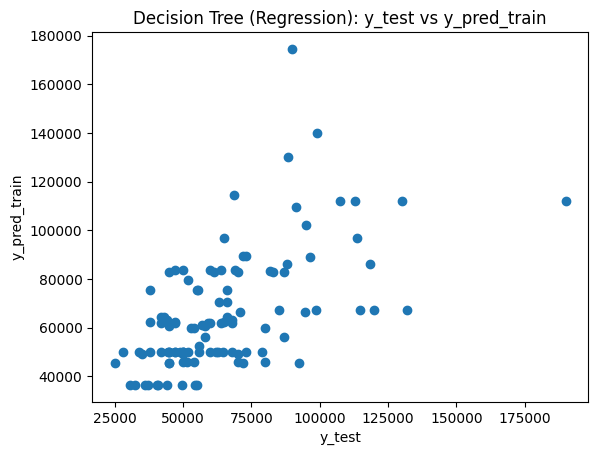

In [17]:
plt.figure()
plt.scatter(y_test, y_pred_train)
plt.xlabel("y_test")
plt.ylabel("y_pred_train")
plt.title("Decision Tree (Regression): y_test vs y_pred_train")
plt.show()

In [18]:
oh = None
if categorical_features:
  oh = best_model.named_steps["preprocessor"].transformers_[1][1].named_steps["onehot"]
num_names = numeric_features
cat_names = oh.get_feature_names_out(categorical_features).tolist() if oh is not None else []
feature_names = num_names + cat_names
feature_names
#

['lotsize',
 'bedrooms',
 'bathrms',
 'stories',
 'garagepl',
 'driveway_no',
 'driveway_yes',
 'recroom_no',
 'recroom_yes',
 'fullbase_no',
 'fullbase_yes',
 'gashw_no',
 'gashw_yes',
 'airco_no',
 'airco_yes',
 'prefarea_no',
 'prefarea_yes']

In [19]:
importances = best_model.named_steps["tree"].feature_importances_
imp_df = (pd.DataFrame({"feature": feature_names if len(feature_names)== len(importances) else [f"f{i}" for i in range(len(importances))]
, "importance": importances})
.sort_values("importance", ascending=False)
.head(10))
imp_df

,feature,importance
0,lotsize,0.511984
2,bathrms,0.156663
4,garagepl,0.074492
13,airco_no,0.074192
3,stories,0.059459
9,fullbase_no,0.042915
1,bedrooms,0.022960
12,gashw_yes,0.022542
7,recroom_no,0.018471
15,prefarea_no,0.011425


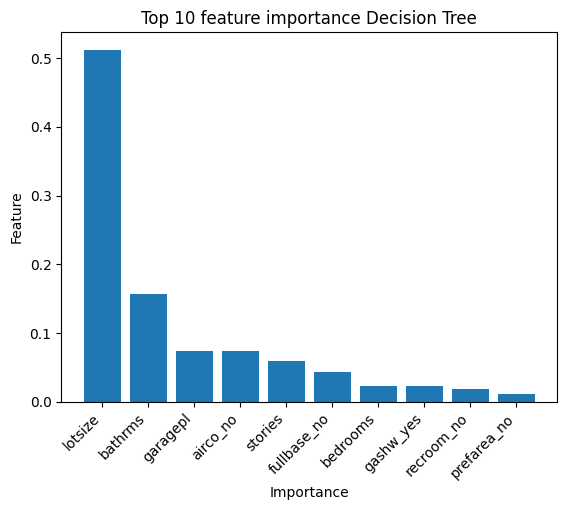

In [20]:
plt.figure()
plt.bar(imp_df["feature"], imp_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 feature importance Decision Tree")
plt.show()
#